## Dimensionality Reduction and Market Factor Analysis (PCA on S&P 500 Stock Returns)

###1. Introduction

This notebook applies Principal Component Analysis (PCA) to historical S&P 500 stock data.
Stock prices are transformed into log returns to ensure stationarity before dimensionality reduction.
The analysis focuses on understanding variance structure and extracting principal components
that capture common market behavior.

###2. Loading the dataset and libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("all_stocks_5yr.csv")
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


The dataset contains daily adjusted prices for S&P 500 stocks.

This extract highlights several features, including the dataset's structure, which allows for duplicate entries for the same stock over time, and columns that will not be used for this project.

###3. Exploratory Data Analysis (EDA)

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB


,open,high,low,close,volume
count,619029.000000,619032.000000,619032.000000,619040.000000,6.190400e+05
mean,83.023334,83.778311,82.256096,83.043763,4.321823e+06
std,97.378769,98.207519,96.507421,97.389748,8.693610e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,40.220000,40.620000,39.830000,40.245000,1.070320e+06
50%,62.590000,63.150000,62.020000,62.620000,2.082094e+06
75%,94.370000,95.180000,93.540000,94.410000,4.284509e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


These statistics reveal a lack of an adequate data distribution for the analysis. Therefore, a data restructuring step is considered necessary to ensure meaningful and reliable results.

In [4]:
print(df["Name"].nunique())
print(df["date"].nunique())

505
1259


There is a discrepancy between the number of available stocks in the dataset and the dates of the existing records, which complicates the objective of dimensionality reduction.

In [5]:
prices = df.pivot(
    index="date",
    columns="Name",
    values="close"
)

prices.head()

Name,A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,...,XL,XLNX,XOM,XRAY,XRX,XYL,YUM,ZBH,ZION,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2013-02-08,45.08,14.75,78.90,67.8542,36.25,46.89,34.41,73.31,39.12,45.70,...,28.24,37.51,88.61,42.87,31.84,27.09,65.30,75.85,24.14,33.05
2013-02-11,44.60,14.46,78.39,68.5614,35.85,46.76,34.26,73.07,38.64,46.08,...,28.31,37.46,88.28,42.84,31.96,27.46,64.55,75.65,24.21,33.26
2013-02-12,44.62,14.27,78.60,66.8428,35.42,46.96,34.30,73.37,38.89,46.27,...,28.41,37.58,88.46,42.87,31.84,27.95,64.75,75.44,24.49,33.74
2013-02-13,44.75,14.66,78.97,66.7156,35.27,46.64,34.46,73.56,38.81,46.26,...,28.42,37.80,88.67,43.08,32.00,28.26,64.41,76.00,24.74,33.55
2013-02-14,44.58,13.99,78.84,66.6556,36.57,46.77,34.70,73.13,38.61,46.54,...,28.22,38.44,88.52,42.91,32.12,28.47,63.89,76.34,24.63,33.27


Data Restructuring for PCA

Restructuring the data using a pivot table makes it possible to organize the data for PCA. The date variable is used to represent time records, name identifies the stock names, and close contains the corresponding closing prices.

In [6]:
prices.isnull().mean().sort_values(ascending=False).head(10)

,0
Name,
APTV,0.965052
DWDP,0.913423
BHF,0.886418
BHGE,0.879269
DXC,0.829230
HLT,0.780778
EVHC,0.764098
FTV,0.679110
UA,0.631454


Missing Data Issue

There are stocks for which the percentage of missing values exceeds 90% of their observations.

In [7]:
threshold = 0.05
prices = prices.loc[:, prices.isnull().mean() < threshold]

Missing Values Filtering

This step filters the dataset to retain only stocks with less than 5% missing data, improving data quality for subsequent analysis.

In [8]:
prices.isnull().mean().sort_values(ascending=False).head(10)

,0
Name,
IQV,0.049245
O,0.012708
DHR,0.012708
ES,0.007943
ICE,0.003971
ORCL,0.001589
BMY,0.001589
NFX,0.000000
NKE,0.000000


Missing Values After Filtering

It can be observed that the highest percentage of missing values now corresponds to approximately 4.9%.

###4. Feature Engineering

In [9]:
returns = np.log(prices / prices.shift(1))
returns = returns.dropna()
returns.head()

Name,A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,...,XL,XLNX,XOM,XRAY,XRX,XYL,YUM,ZBH,ZION,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2013-05-10,0.010831,0.021629,0.008346,-0.008355,0.017255,0.000547,-0.000276,0.004858,0.001136,0.008801,...,-0.001877,0.002077,-0.009825,0.004466,0.000000,-0.002874,0.018504,0.014080,0.005368,-0.011090
2013-05-13,-0.013615,-0.002255,-0.005046,0.003901,-0.010497,-0.006586,0.004964,-0.006983,-0.009358,-0.011608,...,0.004375,-0.017528,-0.000444,-0.014171,-0.012298,-0.009397,-0.020679,0.007279,0.011785,-0.004228
2013-05-14,0.021378,0.021218,0.013090,-0.024217,0.018023,0.008772,0.019074,0.007852,0.009812,0.001944,...,0.019760,0.012067,0.011147,0.017917,0.003369,0.027576,0.017689,0.011439,0.022422,0.001210
2013-05-15,0.038153,0.038477,0.003246,-0.034402,0.014883,0.000909,0.016330,0.002604,0.023119,0.007524,...,-0.000306,0.010118,0.001426,-0.006328,0.008929,0.010192,-0.003284,0.001235,-0.003331,-0.008805
2013-05-16,-0.015220,0.016346,-0.011407,0.013268,0.003903,-0.011151,-0.022286,-0.001859,-0.011380,-0.004078,...,-0.001224,0.000000,-0.005936,-0.008264,-0.027029,0.001398,-0.004156,-0.004579,-0.004459,0.018133


Log-Return Transformation

After filtering, the dataset contains 477 columns, down from the original 505. A logarithmic return transformation is applied to these series in order to analyze relative day-to-day price changes.

This step is necessary because price levels often exhibit trends, and PCA performs poorly when applied directly to non-stationary data.

In [10]:
all_returns = returns.values.flatten()

Matrix Conversion

This line extracts the data from the DataFrame as a NumPy array, converting it from a tabular structure into a matrix.

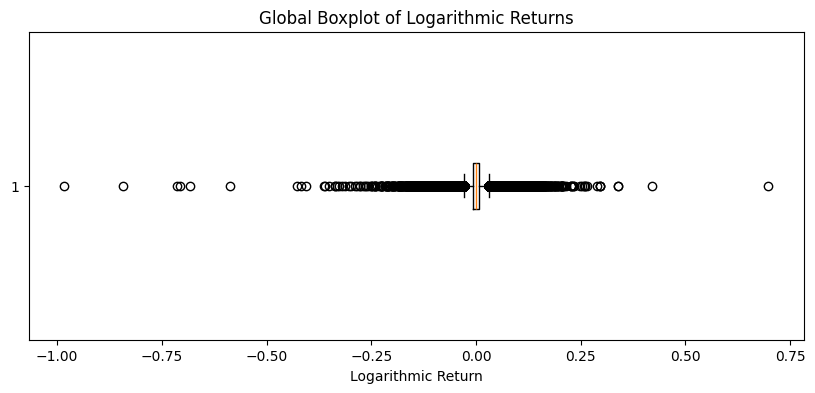

In [11]:
plt.figure(figsize=(10,4))
plt.boxplot(all_returns, vert=False)
plt.title("Global Boxplot of Logarithmic Returns")
plt.xlabel("Logarithmic Return")
plt.show()

Global Log-Returns Analysis

A global analysis of the logarithmic returns shows a median close to zero, indicating similar overall behavior across assets, along with the presence of many outliers, which justifies the use of PCA for dimensionality reduction.

###5. Standardization and Principal Component Analysis (PCA)

In [12]:
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)

Standardization Prior to PCA

Before applying PCA, the returns are standardized to ensure that all stocks contribute equally to the analysis, regardless of their volatility levels.

In [13]:
pca = PCA()
pca.fit(returns_scaled)

PCA()

PCA Fitting

In this step, the PCA algorithm is fitted to the standardized returns. The fit() method learns the variance structure of the data by computing the principal components ordered by their importance.

In [14]:
explained_variance = pca.explained_variance_ratio_

Explained Variance Ratio

This step shows the proportion of total variance explained by each principal component. This metric is key for evaluating the effectiveness of dimensionality reduction and for selecting the optimal number of components.

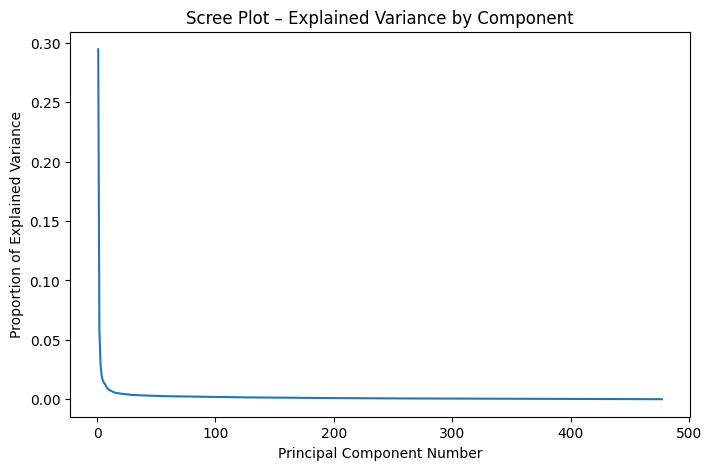

In [15]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance)
plt.xlabel("Principal Component Number")
plt.ylabel("Proportion of Explained Variance")
plt.title("Scree Plot – Explained Variance by Component")
plt.show()

The first components explain a significantly larger fraction of the total variance. A sharp drop is observed in the initial components, indicating a strong correlation among stocks.

Beyond a certain point, additional components contribute only marginal variance. This behavior suggests that the market can be described using a reduced number of latent factors.

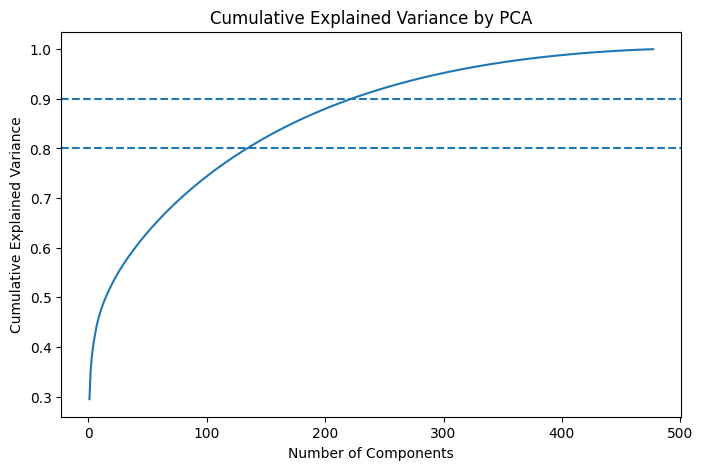

In [16]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by PCA")
plt.axhline(y=0.8, linestyle="--")
plt.axhline(y=0.9, linestyle="--")
plt.show()

Cumulative Explained Variance Analysis

A relatively small number of components explains a large proportion of the total variance. The reference lines at 80% and 90% help guide the selection of an appropriate number of components.

This analysis shows that it is possible to significantly reduce dimensionality without losing relevant information. In particular, reaching approximately 90% of the cumulative explained variance requires around 220 components out of the original 477.

In [17]:
n_components = np.argmax(cumulative_variance >= 0.9) + 1
n_components

np.int64(222)

Component Selection Criterion

The minimum number of components that explains at least 90% of the total variance is selected.

In [18]:
from sklearn.decomposition import PCA

pca_final = PCA(n_components=n_components)
returns_pca = pca_final.fit_transform(returns_scaled)

Dimensionality Reduction with PCA

In this step, PCA is applied using the selected number of components (222). The standardized returns are projected onto the new principal component space, effectively reducing the dimensionality of the data.

In [19]:
returns_scaled.shape

(1170, 477)

Original Number of Components (Before PCA)

In [20]:
returns_pca.shape

(1170, 222)

Final Number of Components (After PCA)

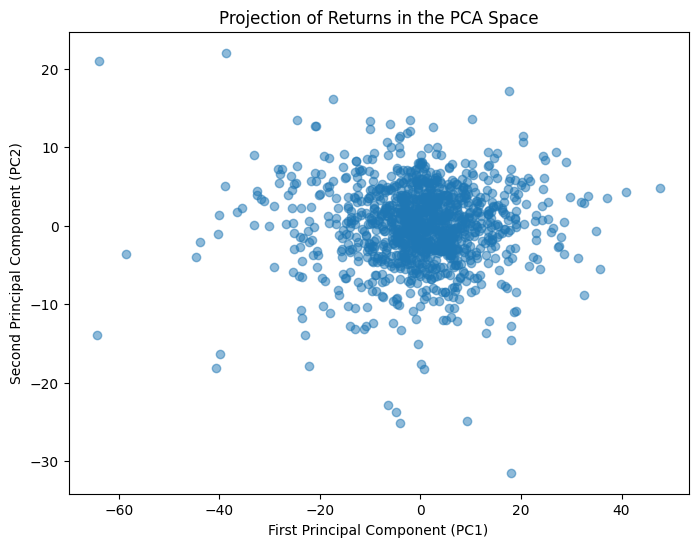

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(returns_pca[:, 0], returns_pca[:, 1], alpha=0.5)
plt.xlabel("First Principal Component (PC1)")
plt.ylabel("Second Principal Component (PC2)")
plt.title("Projection of Returns in the PCA Space")
plt.show()

PCA Projection Visualization

In this plot, each point represents a full trading day combining all stocks. The x-axis shows the dominant market factor, while the y-axis represents the second most important factor.

The compact point cloud indicates a stable market, whereas the extreme points can be interpreted as high-volatility days.

###4. Interpretation of Loadings (Component Weights)

In [22]:
loadings = pd.DataFrame(
    pca_final.components_.T,
    index=returns.columns,
    columns=[f"PC{i+1}" for i in range(n_components)]
)

loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC213,PC214,PC215,PC216,PC217,PC218,PC219,PC220,PC221,PC222
Name,,,,,,,,,,,,,,,,,,,,,
A,0.049353,-0.017304,-0.018275,-0.058648,-0.026740,0.002077,0.018421,-0.000056,0.014173,-0.024468,...,0.032024,-0.030469,0.092589,0.005254,0.069507,0.038050,0.065987,0.004297,0.001649,0.065395
AAL,0.041390,-0.021206,-0.055793,-0.022752,0.025774,0.001141,-0.053624,0.082158,-0.015034,0.074151,...,-0.027790,0.000731,0.011873,-0.047087,-0.022969,0.021035,-0.035531,-0.048731,-0.036295,-0.019640
AAP,0.033132,0.003216,-0.012103,0.038176,0.089922,-0.071148,0.021714,0.038799,-0.024484,-0.013028,...,0.060631,-0.026134,0.067147,0.001771,-0.005111,0.072419,0.132339,0.028180,-0.040690,0.040324
AAPL,0.037856,-0.007921,-0.022137,-0.060144,-0.042971,-0.028284,-0.045536,-0.019647,-0.034876,0.041276,...,0.002324,-0.031461,-0.017756,-0.017166,0.013748,0.095788,0.057620,0.045728,-0.039674,0.039251
ABBV,0.041807,0.003704,-0.033667,-0.067723,0.023174,0.028698,0.120553,0.022466,0.050693,0.029456,...,-0.021535,-0.026632,-0.011110,0.069936,0.127439,-0.020044,0.000197,0.066746,-0.068600,0.030173


This table presents an excerpt of each component along with the stocks associated with them, based on their loading values.

In [23]:
loadings["PC1"].sort_values(ascending=False).head(10)

,PC1
Name,
BLK,0.068535
BRK.B,0.067544
ITW,0.067076
PFG,0.067034
IVZ,0.066915
HON,0.066029
TMK,0.065432
AMP,0.065174
BEN,0.064737


In [24]:
loadings["PC1"].sort_values().head(10)

,PC1
Name,
NEM,0.011423
LNT,0.014343
NI,0.014442
ED,0.020733
EBAY,0.021965
BAX,0.023097
SO,0.023866
O,0.024246
CMG,0.024456


PC1 Loadings Interpretation

The last two plots display the stocks with the highest and lowest loadings within the first principal component (PC1). These loadings indicate how strongly each stock contributes to the factor captured by PC1.

BLK shows one of the highest loadings, suggesting that its behavior is strongly aligned with the dominant market factor. In contrast, NEM exhibits one of the lowest loadings, indicating a weaker contribution or a lower relationship with this factor.

In [25]:
loadings["PC2"].sort_values(ascending=False).head(10)


,PC2
Name,
ED,0.150070
XEL,0.146761
CMS,0.145704
WEC,0.145606
ES,0.144102
DUK,0.141061
PNW,0.140889
SO,0.140426
DTE,0.140369


In [26]:
loadings["PC2"].sort_values().head(10)

,PC2
Name,
ZION,-0.084510
RF,-0.080675
CMA,-0.080546
BAC,-0.080273
LNC,-0.078291
SCHW,-0.077119
FITB,-0.073579
HBAN,-0.073407
MET,-0.073247


PC2 Loadings Interpretation

The last two plots show the stocks with the highest and lowest loadings within the second principal component (PC2). Unlike the first component, PC2 does not represent a general market movement, but rather captures relative differences between groups of stocks.

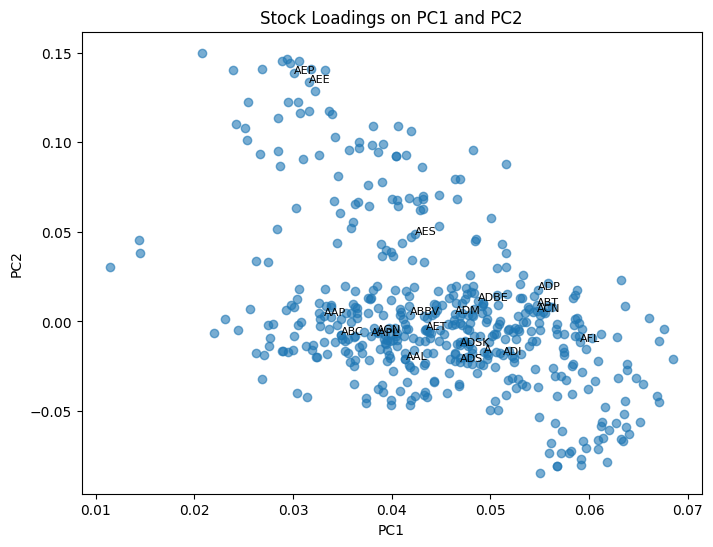

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(loadings["PC1"], loadings["PC2"], alpha=0.6)

for ticker in loadings.index[:20]:
    plt.text(loadings.loc[ticker, "PC1"],
             loadings.loc[ticker, "PC2"],
             ticker,
             fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Stock Loadings on PC1 and PC2")
plt.show()

Overall Loadings Interpretation

The analysis of loadings enables the interpretation of the principal components. The first component represents a general market factor, while the subsequent components capture sectoral differences.

##6. Conclusions
The PCA analysis made it possible to identify latent market factors and to significantly reduce the dimensionality of the data. The extracted principal components can be used as input features for machine learning models, risk analysis, and asset clustering.


##7. Limitations
PCA is a linear method, so it does not capture non-linear relationships between assets.

Principal components do not always have a direct economic interpretation and often require additional analysis.

The results depend on the time period analyzed; extracted factors may change across different market regimes.

PCA is sensitive to outliers, which can affect the estimation of the components.

##8. Next Steps

Analyze the loadings in greater detail to relate the components to market sectors or styles.

Use the principal components as features in machine learning models.

Apply clustering techniques in the PCA space to identify groups of stocks or market regimes.

Compare PCA with non-linear dimensionality reduction methods, such as autoencoders.